In [174]:
import json
import os

safe_data_path = os.path.join(os.getcwd(), "data_for_git", "rated_facts.jsonl")
safe_data = []
with open(safe_data_path, "r") as f:
    for line in f:
        safe_data.append(json.loads(line))



In [175]:
query_stats = {}
for generation in safe_data:
    number_of_facts = 0
    generation_facts = 0
    generation_facts_supported = 0
    for sentence_facts in generation["results"]["all_atomic_facts"]:
        for fact in sentence_facts["atomic_facts"]:
            number_of_facts += 1
            generation_facts += 1
            if fact["rating"] == "Supported":
                generation_facts_supported += 1
    if query_stats.get(generation["id"]) is None:
        query_stats[generation["id"]] = [{
            "generation_facts": generation_facts,
            "generation_facts_supported": generation_facts_supported
        }]
    else:
        query_stats[generation["id"]].append({
            "generation_facts": generation_facts,
            "generation_facts_supported": generation_facts_supported
        })


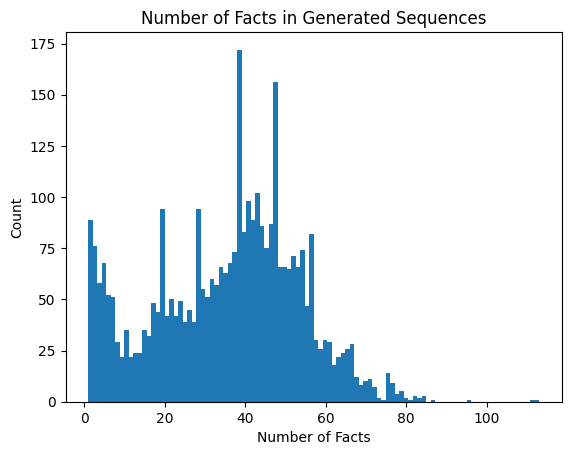

In [176]:
from matplotlib import pyplot as plt
all_generation_stats = []
for query in query_stats.values():
    for generation_stat in query:
        generation_stat["correct_percentage"] = generation_stat["generation_facts_supported"]/generation_stat["generation_facts"]
        all_generation_stats.append(generation_stat)

plt.hist([x["generation_facts"] for x in all_generation_stats], bins=100)
# plt.show()
plt.xlabel('Number of Facts')
plt.ylabel('Count')
plt.title('Number of Facts in Generated Sequences')
plt.savefig('generation_facts_histogram.png')
# plt.hist([x["correct_percentage"] for x in all_generation_stats], bins=100)
# plt.show()


In [177]:
safe_data_dict = {}
for generation in safe_data:
    safe_data_dict[generation["id"]] = generation


In [178]:
number_of_supported_facts = 0
number_of_facts = 0
for generation in safe_data:
    for sentence in generation["results"]["all_atomic_facts"]:
        for fact in sentence["atomic_facts"]:
            number_of_facts += 1
            if fact["rating"] == "Supported":
                number_of_supported_facts += 1
print(number_of_supported_facts / number_of_facts)

0.2615656371890786


In [179]:
black_box_path = os.path.join(os.getcwd(), "results", "black_box_results.jsonl")
white_box_path = os.path.join(os.getcwd(), "results", "white_box_results.jsonl")

black_box_results = []
white_box_results = []

with open(black_box_path, "r") as f:
    for line in f:
        black_box_results.append(json.loads(line))

with open(white_box_path, "r") as f:
    for line in f:
        white_box_results.append(json.loads(line))


In [180]:
import numpy as np
def prec(generation):
    facts_supported = 0
    facts = 0
    for sentence in generation["results"]["all_atomic_facts"]:
        for fact in sentence["atomic_facts"]:
            facts += 1
            if fact["rating"] == "Supported":
                facts_supported += 1
    return facts_supported / facts


def rec_K(generation, k):
    facts_supported = 0
    for sentence in generation["results"]["all_atomic_facts"]:
        for fact in sentence["atomic_facts"]:
            if fact["rating"] == "Supported":
                facts_supported += 1
    return min(facts_supported / k, 1)

def f1_K(generation, k):
    precision = prec(generation)
    recall = rec_K(generation, k)
    if precision + recall == 0:
        return 0
    return 2 * precision * recall / (precision + recall)

all_number_of_facts = []
for generation in safe_data:
    number_of_facts = 0
    for sentence in generation["results"]["all_atomic_facts"]:
        number_of_facts += len(sentence["atomic_facts"])
    all_number_of_facts.append(number_of_facts)

def get_number_of_facts(generation):
    number_of_facts = 0
    for sentence in generation["results"]["all_atomic_facts"]:
        number_of_facts += len(sentence["atomic_facts"])
    return number_of_facts

mean_number_of_facts = np.mean([get_number_of_facts(generation) for generation in safe_data_dict.values()])
k = int(np.ceil(mean_number_of_facts))
k

37

In [181]:
cluster_data_path = os.path.join(os.getcwd(), "data", "query_hierarchical_clusters.jsonl")
cluster_data = []
with open(cluster_data_path, "r") as f:
    for line in f:
        cluster_data.append(json.loads(line))

In [182]:
avg_number_of_facts = {}
for sequence in cluster_data:
    total = 0
    for id in sequence["sequence_ids"]:
        total += get_number_of_facts(safe_data_dict[id])
    for id in sequence["sequence_ids"]:
        avg_number_of_facts[id] = total / len(sequence["sequence_ids"])

print(len(avg_number_of_facts))

3413


In [183]:


nlls = []
nlls_normalized = []
nll_norm_presence = []
uncertainties = []
precisions = []
recalls = []
f1s = []
all_number_of_facts = []
for result in black_box_results:
    ids = result["sequence_ids"]
    for id in ids:
        for white_box_result in white_box_results:
            if white_box_result["sequence_id"] == id:
                no_facts = get_number_of_facts(safe_data_dict[id])
                # find clusters using sequence id and cluster_data
                presence = 0
                for query in cluster_data:
                    if id in query["sequence_ids"]:
                        idx = query["sequence_ids"].index(id)
                        for cluster in query["clusters"]:
                            presence += cluster["sequence_presence"][idx]
                        break
                if no_facts < 50:
                    continue
                k = avg_number_of_facts[id]
                all_number_of_facts.append(no_facts)
                nlls.append(white_box_result["nll"])
                nlls_normalized.append(white_box_result["nll"] / no_facts)
                nll_norm_presence.append(white_box_result["nll"] / presence)
                uncertainties.append(result["uncertainty"])
                precisions.append(prec(safe_data_dict[id]))
                recalls.append(rec_K(safe_data_dict[id], k))
                f1s.append(f1_K(safe_data_dict[id], k))
                break
print(len(nlls))

802


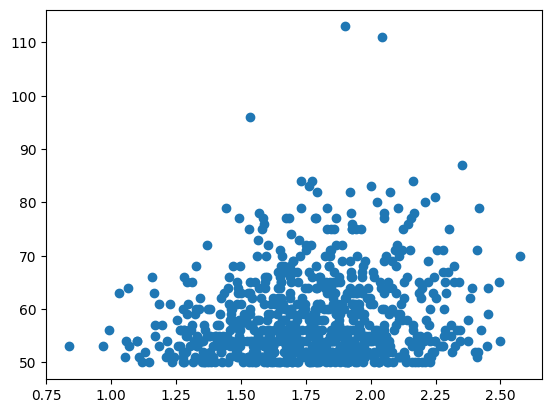

In [184]:
plt.scatter(nll_norm_presence, all_number_of_facts)
plt.show()

58.32793017456359
802


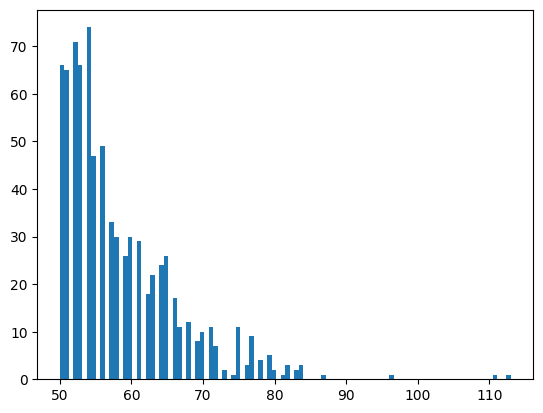

In [185]:

print(np.mean(all_number_of_facts))
print(len(all_number_of_facts))
plt.hist(all_number_of_facts, bins=100)
plt.show()



0.6738870494684528


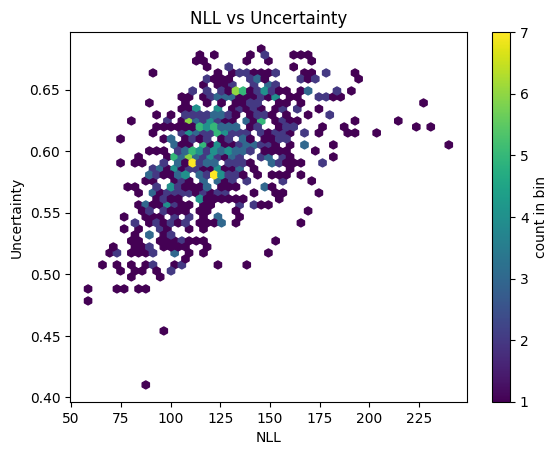

In [186]:
import numpy as np

correlation = np.corrcoef(nlls_normalized, uncertainties)[0, 1]
print(correlation)

plt.hexbin(
    nlls, 
    uncertainties, 
    gridsize=50, 
    cmap='viridis',
    mincnt=1
)
plt.colorbar(label='count in bin')
plt.xlabel('NLL')
plt.ylabel('Uncertainty')
plt.title('NLL vs Uncertainty')
plt.show()

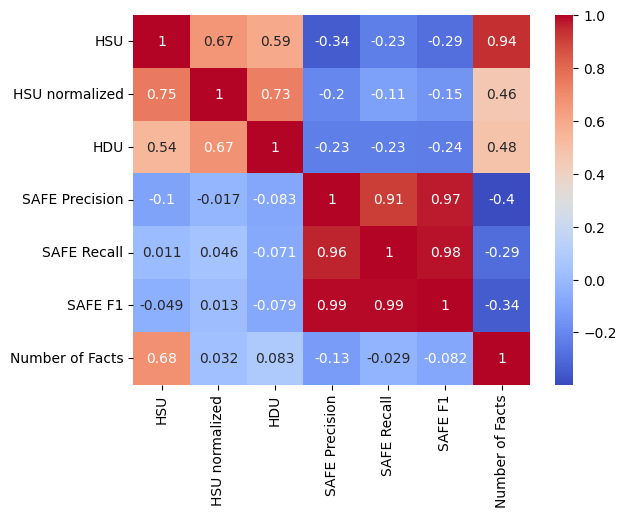

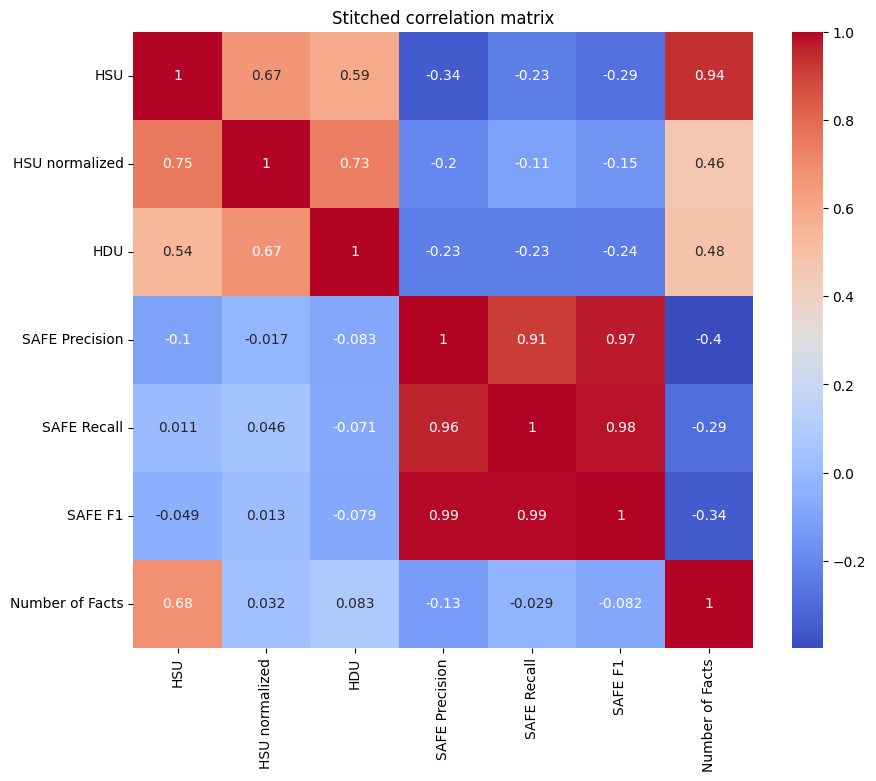

In [192]:
import seaborn as sns

# make a correlation matrix of all the aligned_white, aligned_black, aligned_safe_prec, aligned_safe_rec, aligned_safe_f1
correlation_matrix = np.corrcoef([nlls, nlls_normalized, uncertainties, precisions, recalls, f1s, all_number_of_facts])
# correlation_long_sequences = np.corrcoef([nlls, nlls_normalized, uncertainties, precisions, recalls, f1s, all_number_of_facts])
# make heatmap with labels
mixed_matrix = np.triu(correlation_long_sequences) + np.tril(correlation_matrix) - np.diag(np.diag(correlation_matrix))


tick_labels = ['HSU', 'HSU normalized', 'HDU', 'SAFE Precision', 'SAFE Recall', 'SAFE F1', 'Number of Facts']
sns.heatmap(mixed_matrix, annot=True, cmap='coolwarm', xticklabels=tick_labels, yticklabels=tick_labels)
plt.show()

# create png of the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(mixed_matrix, annot=True, cmap='coolwarm', xticklabels=tick_labels, yticklabels=tick_labels)
plt.title('Stitched correlation matrix')
plt.savefig('heatmap.png')



In [188]:
cluster_stats = []
for query in cluster_data:
    facts = []
    for id in query["sequence_ids"]:
        for sentence in safe_data_dict[id]["results"]["all_atomic_facts"]:
            facts.extend(sentence["atomic_facts"])
    for fact in facts:
        for cluster in query["clusters"]:
            for cluster_fact in cluster["atomic_facts"]:
                if fact["fact"] == cluster_fact["atomic_fact"]:
                    cluster_fact["rating"] = fact["rating"]
    for cluster in query["clusters"]:
        supported_facts = 0
        facts = 0
        for cluster_fact in cluster["atomic_facts"]:
            facts += 1
            if cluster_fact["rating"] == "Supported":
                supported_facts += 1
        cluster_stats.append({"support_percentage": supported_facts / facts, "number_of_facts": sum(cluster["sequence_presence"])})


In [189]:
# Analyze support vs. entailment: how often does a supporting cluster entail a non-supporting one?
fallacy_cases = []
edge_count = 0
fallacy_count = 0

for q_idx, query in enumerate(cluster_data):
    clusters = query["clusters"]
    adj = query.get("adj", [])  # u -> v means u entails v

    # compute support rate per cluster (using ratings already attached above)
    support_rate = []
    for c in clusters:
        facts = c.get("atomic_facts", [])
        if not facts:
            support_rate.append(0.0)
            continue
        supported = sum(1 for f in facts if f.get("rating") == "Supported")
        support_rate.append(supported / len(facts))

    # examine entailment edges
    for u, nbrs in enumerate(adj):
        for v in nbrs:
            edge_count += 1
            u_supported = support_rate[u] > 0.5
            v_supported = support_rate[v] > 0.5
            if u_supported and not v_supported:
                fallacy_count += 1
                fallacy_cases.append({
                    "query_index": q_idx,
                    "entailed_from": clusters[u].get("representative", {}).get("atomic_fact", ""),
                    "entailed_to": clusters[v].get("representative", {}).get("atomic_fact", ""),
                    "support_rate_from": support_rate[u],
                    "support_rate_to": support_rate[v],
                })

print(f"Total entailment edges checked: {edge_count}")
print(f"Fallacy edges (support -> not-supported): {fallacy_count}")
if edge_count:
    print(f"Rate: {fallacy_count/edge_count:.4f}")

# fallacy_cases now contains the examples for inspection


Total entailment edges checked: 43176
Fallacy edges (support -> not-supported): 4620
Rate: 0.1070


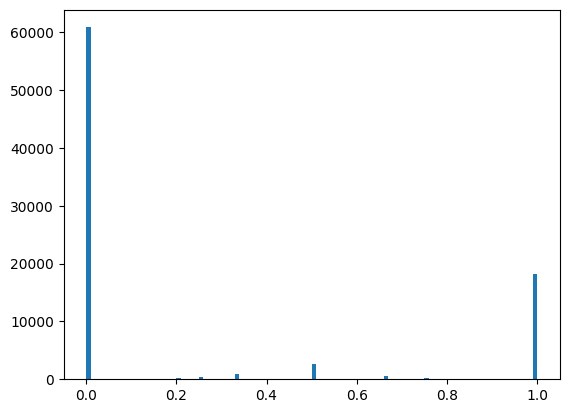

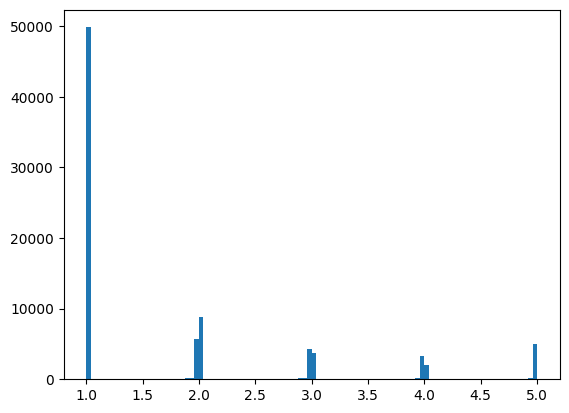

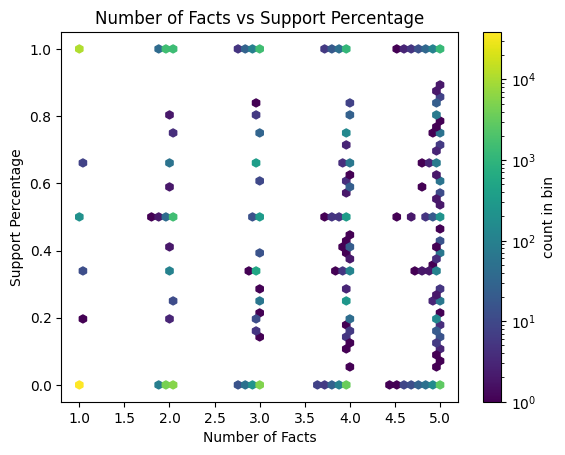

0.08007991025738471


In [190]:
from matplotlib.colors import LogNorm



plt.hist([x["support_percentage"] for x in cluster_stats], bins=100)
plt.show()
plt.hist([x["number_of_facts"] for x in cluster_stats], bins=100)
plt.show()
norm = LogNorm()
hb = plt.hexbin(
    [x["number_of_facts"] for x in cluster_stats],
    [x["support_percentage"] for x in cluster_stats],
    gridsize=50,
    cmap="viridis",
    mincnt=1,
    norm=norm,
)
plt.colorbar(hb, label="count in bin", norm=norm)
plt.xlabel('Number of Facts')
plt.ylabel('Support Percentage')
plt.title('Number of Facts vs Support Percentage')
plt.show()
print(np.corrcoef([x["number_of_facts"] for x in cluster_stats], [x["support_percentage"] for x in cluster_stats])[0, 1])